In [264]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [265]:
# Last inn datasettet
data = pd.read_csv("datasett-biler-ny.csv", sep=";")

# Fjerner unødvendige mellomrom
data.columns = data.columns.str.strip() 

# Fjerner rader med manglende verdier
data = data.dropna()

# Konverter kategoriske kolonner til numeriske (One-hot encoding)
data_encoded = pd.get_dummies(data, columns=["Brand", "Model", "Fuel_Type", "Transmission"], drop_first=True)

# Splitt data i input (X) og målvariabel (y)
X = data_encoded.drop(columns=["Price"])
y = data_encoded["Price"]


In [266]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_columns = X.columns  # Lagre kolonnenavnene

# Opprett DataFrame med skalerte verdier og de originale kolonnenavnene
X_scaled = pd.DataFrame(X_scaled, columns=X_columns)

                                
# Bruk X_scaled i stedet for X i resten av koden
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [267]:
# Gradient Boosting-modell
model = GradientBoostingRegressor(random_state=42).fit(pd.DataFrame(X_train, columns=X_columns), y_train)
model.fit(X_train, y_train)

# Gjør prediksjoner og evaluer modellen
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Gradient Boosting – MSE: {mse:.2f}, R2: {r2:.2f}")

Gradient Boosting – MSE: 818014.93, R2: 0.94


In [268]:
# Gjør prediksjoner
y_pred = model.predict(X_test)

# Evaluer modellen
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 818014.93
R² Score: 0.94


In [269]:
scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print(f"Kryssvalidering R2-score: {scores}")
print(f"Gjennomsnittlig R2-score: {scores.mean():.2f}")


Kryssvalidering R2-score: [0.87254486 0.93185344 0.94123881 0.93641676 0.90273221]
Gjennomsnittlig R2-score: 0.92


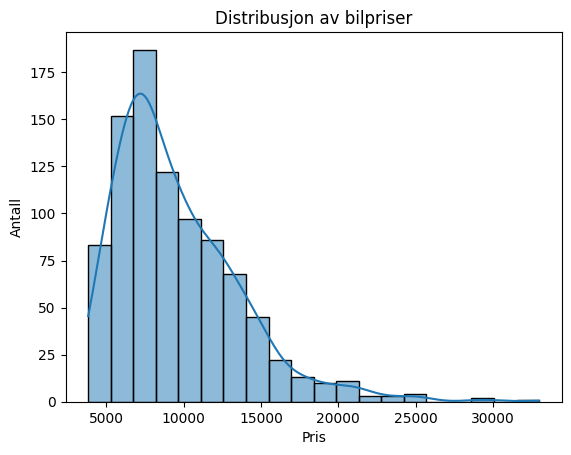

In [270]:
# Histogram av prisene
sns.histplot(data['Price'], kde=True, bins=20)
plt.title("Distribusjon av bilpriser")
plt.xlabel("Pris")
plt.ylabel("Antall")
plt.show()



Dette diagrammet viser fordelingen av bilpriser i datasettet.
Flesteparten av bilene har priser mellom 5 000 og 10 000.
Histogrammet inkluderer en kjerne-tetthetskurve (kde) som viser den glatte fordelingen.

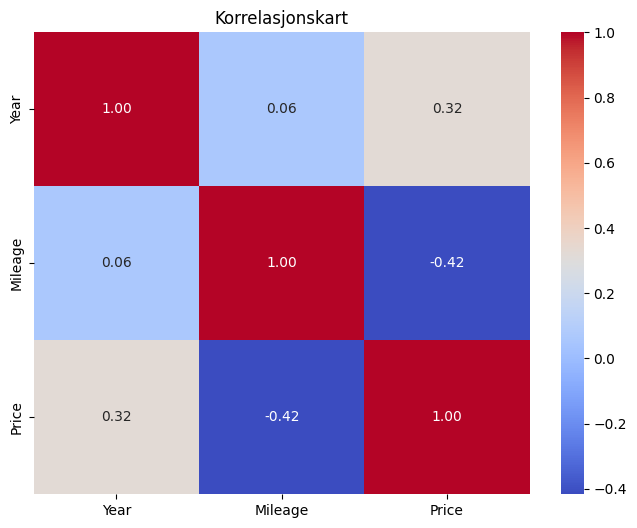

In [271]:
# Korrelasjonskart
numeric_data = data.select_dtypes(include=[np.number])  # Velg kun numeriske kolonner
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korrelasjonskart")
plt.show()

Dette er en heatmap som viser korrelasjonen mellom numeriske variabler i datasettet. 
Positive korrelasjoner (røde) betyr at variablene øker sammen, mens negative korrelasjoner (blå) betyr at når én variabel øker, reduseres den andre.
Eksempel: Pris har en svak positiv korrelasjon med Year (0.32) og en negativ korrelasjon med Mileage (-0.42).

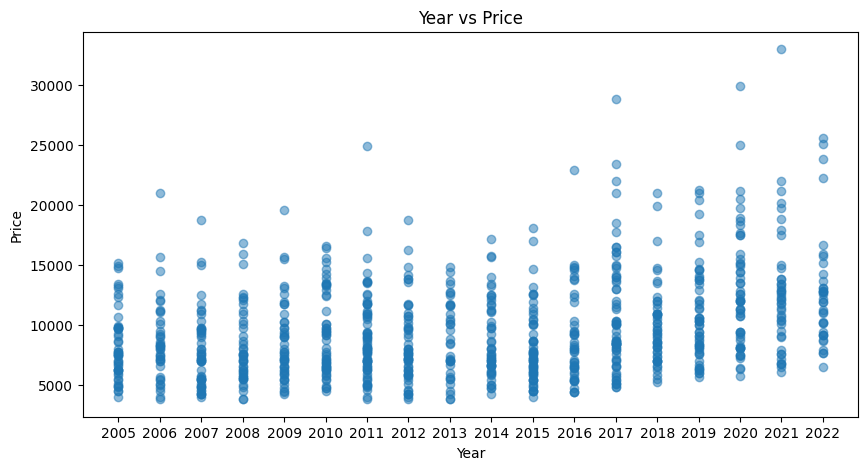

In [272]:
import matplotlib.ticker as mticker

plt.figure(figsize=(10, 5))
plt.scatter(data['Year'], data['Price'], alpha=0.5)
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))  # Setter årstall til hele tall
plt.show()


Denne viser hvordan bilprisene endres basert på produksjonsår.
Generelt ser vi at nyere biler har en tendens til å ha høyere priser, mens eldre biler har lavere priser.
Diagrammet bruker punkter for å vise sammenhengen mellom år og pris, med hele tall på x-aksen (år).

In [273]:
 # Eksempeldata for en ny bil
ny_bil = {
    "Year": 2017,
    "Mileage": 25000,
    "Brand_BMW": 0,
    "Brand_Toyota": 0,
    "Model_Corolla": 0,
    "Model_Focus": 1,
    "Fuel_Type_Petrol": 1,
    "Fuel_Type_Diesel": 0,
    "Transmission_Manual": 0,
    "Transmission_Automatic": 1,
}

# Opprett en ny rad som DataFrame
ny_bil_df = pd.DataFrame([ny_bil])

# Kombiner med X_train og tilpass kolonnene
ny_bil_df = pd.concat([X_train, ny_bil_df], ignore_index=True)
ny_bil_df = ny_bil_df.reindex(columns=X_train.columns, fill_value=0)

# Fyll eventuelle manglende verdier med 0 i `ny_bil_df`
ny_bil_df = ny_bil_df.fillna(0)

# Skaler `ny_bil_df` med samme scaler som tidligere
ny_bil_scaled = scaler.transform(ny_bil_df)

# Gjør en prediksjon for kun den siste raden (ny bil)
predicted_price = model.predict(ny_bil_scaled[-1:])
print(f"Estimert pris for bilen: ${predicted_price[0]:.2f}")

Estimert pris for bilen: $14636.21


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
